# Run Log Results Plotter

Use this notebook to compare VFA, hybrid, or future simulation run logs. Add one or more folders to `RUN_LOGS`; each folder is searched recursively for `results.csv`, so a parent folder containing many experiments works directly.

In [199]:
from pathlib import Path
import os
import re
import tempfile

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "fomosim_matplotlib"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

WORKSPACE_ROOT = Path.cwd()
while WORKSPACE_ROOT.name != "FOMOsim" and WORKSPACE_ROOT.parent != WORKSPACE_ROOT:
    WORKSPACE_ROOT = WORKSPACE_ROOT.parent

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

WORKSPACE_ROOT

PosixPath('/Users/minasjovik/Projects/FOMOsim')

## Configuration

Edit `RUN_LOGS` and `METRICS`. By default the notebook scans every `results.csv` under `run_logs`, while skipping helper/archive folders listed in `EXCLUDED_RUN_LOG_DIRS`. You can still give exact run folders, parent folders, direct `results.csv` paths, or glob patterns such as `run_logs/run_20260509_*`.

In [200]:
RUN_LOGS = ["run_logs"]
EXCLUDED_RUN_LOG_DIRS = {"HISTORY", "history", "before_depot_fix", "plots", "__pycache__"}

# Choose any columns from results.csv. Run the "Available columns" cell below to inspect options.
METRICS = ["service_level", "starvations", "congestions","total_depot_visits","total_fixed_on_site","total_picked_up_to_depot","total_functional_pickups","broken_ratio_end_onsite","broken_ratio_end_depot","functional_ratio_end", "total_trips",]

SORT_BY = "service_level"
OUTPUT_DIR = WORKSPACE_ROOT / "run_logs" / "plots" / "baseline_candidates"
SAVE_OUTPUTS = True
SAVE_SUMMARY_TABLE_CSV = True

METRIC_LABELS = {
    "total_trips": "Total trips",
    "service_level": "Service level",
    "starvations": "Starvations",
    "congestions": "Congestions",
    "avg_bike_km_driven": "Avg. bike km driven",
    "total_depot_visits": "Depot visits",
    "total_depot_deliveries": "Depot deliveries",
    "total_fixed_on_site": "Fixed on site",
    "total_picked_up_to_depot": "Picked up to depot",
    "total_depot_fixes": "Depot fixes",
    "total_functional_pickups": "Functional pickups",
    "total_functional_deliveries": "Functional deliveries",
    "broken_ratio_end_onsite": "End broken ratio onsite",
    "broken_ratio_end_depot": "End broken ratio depot",
    "functional_ratio_end": "End functional ratio",
}

## Helper Functions

In [201]:
def resolve_input(raw_path: str) -> list[Path]:
    raw_path = str(raw_path).rstrip(". \t")   # strip accidental trailing dots or spaces
    base_pattern = raw_path if Path(raw_path).is_absolute() else str(WORKSPACE_ROOT / raw_path)
    matches = sorted(Path(p) for p in __import__("glob").glob(base_pattern))
    if not matches:
        matches = [Path(base_pattern)]
    return matches


def find_results_csv(run_logs) -> list[Path]:
    # Each entry may be a plain string/path OR a list of strings to combine.
    flat: list[str] = []
    for entry in run_logs:
        if isinstance(entry, (list, tuple)):
            flat.extend(str(p) for p in entry)
        else:
            flat.append(str(entry))

    paths = []

    def is_excluded(candidate: Path) -> bool:
        try:
            relative_parts = candidate.relative_to(WORKSPACE_ROOT / "run_logs").parts
        except ValueError:
            relative_parts = candidate.parts
        return any(part in EXCLUDED_RUN_LOG_DIRS for part in relative_parts)

    for raw in flat:
        for path in resolve_input(raw):
            if is_excluded(path):
                continue
            if path.is_file() and path.name == "results.csv":
                if not is_excluded(path):
                    paths.append(path)
            elif path.is_dir():
                for csv_path in sorted(path.rglob("results.csv")):
                    if not is_excluded(csv_path):
                        paths.append(csv_path)
            else:
                print(f"Warning: input not found, skipping: {raw}")
    return list(dict.fromkeys(paths))


def strip_known_suffixes(name: str) -> str:
    name = re.sub(r"_seed\d+.*$", "", name)
    name = re.sub(r"_TD_W\d+.*$", "", name)
    name = re.sub(r"_OS_W\d+.*$", "", name)
    name = re.sub(r"_EH_.*$", "", name)
    return name.strip("_")


def experiment_from_path(csv_path: Path) -> tuple[str, str]:
    folder = csv_path.parent.name
    if folder.startswith("hybrid_"):
        return "Hybrid", strip_known_suffixes(folder.removeprefix("hybrid_"))
    if folder.startswith("vfa_"):
        return "VFA", strip_known_suffixes(folder.removeprefix("vfa_"))
    if folder.startswith("greedy-maintenance_") or folder.startswith("GreedyMaintenance_"):
        return "Greedy", "Greedy maintenance"
    if folder.startswith("DoNothing_"):
        return "DoNothing", "Do nothing"

    try:
        first = pd.read_csv(csv_path, nrows=1)
        exp_name = str(first["exp_name"].iloc[0]) if "exp_name" in first else folder
    except Exception:
        exp_name = folder
    return "Unknown", strip_known_suffixes(exp_name)


def pretty_experiment(name: str) -> str:
    aliases = {
        "R4_NetTemporalAlternative": "Net temporal",
        "R6_BreadthDepth": "Squared count",
    }
    return aliases.get(name, name.replace("_", " "))


def load_results(run_logs: list[str]) -> pd.DataFrame:
    rows = []
    for csv_path in find_results_csv(run_logs):
        policy, experiment = experiment_from_path(csv_path)
        try:
            df = pd.read_csv(csv_path)
        except Exception as exc:
            print(f"Warning: could not read {csv_path}: {exc}")
            continue

        df["policy"] = policy
        df["experiment"] = experiment
        df["experiment_label"] = pretty_experiment(experiment)
        df["label"] = df["policy"] + ": " + df["experiment_label"]
        df["source"] = str(csv_path.relative_to(WORKSPACE_ROOT))
        rows.append(df)

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def summarize_results(df: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    missing = [metric for metric in metrics if metric not in df.columns]
    if missing:
        raise ValueError(f"Missing metric columns: {missing}")

    grouped = df.groupby(["policy", "experiment", "experiment_label", "label"], dropna=False)
    parts = []
    for metric in metrics:
        stats = grouped[metric].agg(mean="mean", std="std", n="count").reset_index()
        stats["metric"] = metric
        parts.append(stats)
    return pd.concat(parts, ignore_index=True)


def ordered_labels(summary: pd.DataFrame, sort_by: str | None) -> list[str]:
    if sort_by and sort_by in set(summary["metric"]):
        ranking = summary[summary["metric"] == sort_by].sort_values("mean", ascending=False)
        return ranking["label"].tolist()
    return sorted(summary["label"].unique())


def wide_summary(summary: pd.DataFrame, metrics: list[str], sort_by: str | None) -> pd.DataFrame:
    labels = ordered_labels(summary, sort_by)
    mean_wide = summary.pivot(index="label", columns="metric", values="mean").reindex(labels)
    std_wide = summary.pivot(index="label", columns="metric", values="std").reindex(labels)
    n_values = summary[summary["metric"] == metrics[0]].set_index("label")["n"].reindex(labels)

    cols = []
    for metric in metrics:
        cols.extend([(metric, "mean"), (metric, "std")])

    out = pd.concat({"mean": mean_wide, "std": std_wide}, axis=1).swaplevel(axis=1)
    out = out.reindex(columns=pd.MultiIndex.from_tuples(cols))
    out.insert(0, ("n", ""), n_values)
    return out


def plot_metric_bars(summary: pd.DataFrame, metrics: list[str], sort_by: str | None = "service_level"):
    available_metrics = [m for m in metrics if m in set(summary["metric"])]
    labels = ordered_labels(summary, sort_by)

    fig_height = max(4.0, 0.38 * len(labels) * len(available_metrics))
    fig, axes = plt.subplots(1, len(available_metrics), figsize=(5.2 * len(available_metrics), fig_height), squeeze=False)
    y = np.arange(len(labels))

    for ax, metric in zip(axes[0], available_metrics):
        metric_summary = summary[summary["metric"] == metric].set_index("label").reindex(labels).reset_index()
        means = metric_summary["mean"].to_numpy(dtype=float)
        stds = metric_summary["std"].fillna(0.0).to_numpy(dtype=float)

        ax.barh(y, means, xerr=stds, color="#4C78A8", alpha=0.9)
        ax.set_title(METRIC_LABELS.get(metric, metric.replace("_", " ").title()))
        ax.invert_yaxis()
        ax.grid(axis="x", alpha=0.25)
        if metric == available_metrics[0]:
            ax.set_yticks(y, labels)
        else:
            ax.set_yticks(y, [])

        for yi, value in zip(y, means):
            if not np.isnan(value):
                txt = f"{value:.4f}" if abs(value) < 10 else f"{value:.0f}"
                ax.text(value, yi, f"  {txt}", va="center", fontsize=8)

    fig.tight_layout()
    return fig

## Load Results

In [202]:
MANDATORY_EXCLUDED_RUN_LOG_DIRS = {"HISTORY", "history", "before_depot_fix", "plots", "__pycache__"}
EXCLUDED_RUN_LOG_DIRS = set(globals().get("EXCLUDED_RUN_LOG_DIRS", set())) | MANDATORY_EXCLUDED_RUN_LOG_DIRS

def path_is_excluded(candidate: Path) -> bool:
    try:
        relative_parts = candidate.relative_to(WORKSPACE_ROOT / "run_logs").parts
    except ValueError:
        relative_parts = candidate.parts
    return any(part in EXCLUDED_RUN_LOG_DIRS for part in relative_parts)

# Do the recursive scan here directly so stale helper functions in the Jupyter
# kernel cannot accidentally include archived folders.
results_csv = []
for root in RUN_LOGS:
    root_path = Path(root)
    if not root_path.is_absolute():
        root_path = WORKSPACE_ROOT / root_path
    for csv_path in sorted(root_path.rglob("results.csv")):
        if not path_is_excluded(csv_path):
            results_csv.append(csv_path)
results_csv = list(dict.fromkeys(results_csv))

print(f"Found {len(results_csv)} results.csv files after exclusions: {sorted(EXCLUDED_RUN_LOG_DIRS)}")
for path in results_csv:
    print(path.relative_to(WORKSPACE_ROOT))

Found 10 results.csv files after exclusions: ['HISTORY', '__pycache__', 'before_depot_fix', 'history', 'plots']
run_logs/run_20260512_084959/hybrid_Squared_temporal_seed1000_bias_term_trans100_fsdiag25_g0.97_eps0_initbm2p5_TD_W34_old_D504h_V1/results.csv
run_logs/run_20260512_085006/hybrid_R4_NetTemporalAlternative_seed1000_bias_term_trans100_fsdiag25_g0.97_eps0_initbm2p5_TD_W34_old_D504h_V1/results.csv
run_logs/run_20260512_085009/hybrid_Imbalance_temporal_seed1000_bias_term_trans100_fsdiag25_g0.97_eps0_initbm2p5_TD_W34_old_D504h_V1/results.csv
run_logs/run_20260512_085012/hybrid_Imbalance_severity_temporal_seed1000_bias_term_trans100_fsdiag25_g0.97_eps0_initbm2p5_TD_W34_old_D504h_V1/results.csv
run_logs/run_20260512_085028/hybrid_Imbalance_severity_squared_temporal_seed1000_bias_term_trans100_fsdiag25_g0.97_eps0_initbm2p5_TD_W34_old_D504h_V1/results.csv
run_logs/run_20260512_131833/vfa_Squared_temporal_seed1000_bias_term_trans100_fsdiag25_g0.97_eps0_initbm2p5_TD_W34_old_D504h_V1/resu

In [203]:
# Load only the filtered CSVs from results_csv. This prevents stale kernel state
# from re-scanning run_logs and re-including excluded folders.
if "results_csv" not in globals():
    raise RuntimeError("Run the 'Load Results' discovery cell above first.")

blocked = [path for path in results_csv if path_is_excluded(path)]
if blocked:
    blocked_text = "\n".join(str(p) for p in blocked[:20])
    raise ValueError("Excluded run logs leaked into results_csv:\n" + blocked_text)

rows = []
for csv_path in results_csv:
    policy, experiment = experiment_from_path(csv_path)
    try:
        one = pd.read_csv(csv_path)
    except Exception as exc:
        print(f"Warning: could not read {csv_path}: {exc}")
        continue
    one["policy"] = policy
    one["experiment"] = experiment
    one["experiment_label"] = pretty_experiment(experiment)
    one["label"] = one["policy"] + ": " + one["experiment_label"]
    one["source"] = str(csv_path.relative_to(WORKSPACE_ROOT))
    rows.append(one)

df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
if not df.empty and df["source"].apply(lambda source: path_is_excluded(WORKSPACE_ROOT / source)).any():
    leaked = df.loc[df["source"].apply(lambda source: path_is_excluded(WORKSPACE_ROOT / source)), "source"].unique()
    leaked_text = "\n".join(leaked[:20])
    raise ValueError("Excluded run logs leaked into df:\n" + leaked_text)

print(f"Loaded {len(df)} seed rows from {df['label'].nunique() if not df.empty else 0} experiments")
df.head()

Loaded 100 seed rows from 10 experiments


,seed,exp_name,alpha,duration_hours,total_runtime_s,service_level,avg_bike_km_driven,starvations,congestions,total_trips,bike_departures,bike_arrivals,total_depot_deliveries,total_depot_visits,total_fixed_on_site,total_picked_up_to_depot,total_depot_fixes,total_bikes_redistributed_from_depot,total_functional_pickups,total_functional_deliveries,broken_ratio_start_onsite,broken_ratio_start_depot,functional_ratio_start,broken_ratio_end_onsite,broken_ratio_end_depot,functional_ratio_end,broken_bikes_end_onsite,broken_bikes_end_depot,new_breakdowns_onsite,new_breakdowns_depot,restored_onsite,restored_depot,policy,experiment,experiment_label,label,source
0,42,Squared_temporal_seed1000_bias_term_trans100_f...,0.0,504,40320,0.9430,400.5276,2528,908,60282,57754,57753,217,42,207,217,217,207,6822,7042,0.0157,0.0328,0.9514,0.0143,0.0574,0.9283,11,44,207,225,207,207,Hybrid,Squared_temporal,Squared temporal,Hybrid: Squared temporal,run_logs/run_20260512_084959/hybrid_Squared_te...
1,43,Squared_temporal_seed1000_bias_term_trans100_f...,0.0,504,40320,0.9475,398.2832,2254,900,60062,57808,57809,189,42,211,189,189,179,6966,7165,0.0079,0.0329,0.9593,0.0196,0.0392,0.9413,15,30,221,188,211,179,Hybrid,Squared_temporal,Squared temporal,Hybrid: Squared temporal,run_logs/run_20260512_084959/hybrid_Squared_te...
2,44,Squared_temporal_seed1000_bias_term_trans100_f...,0.0,504,40320,0.9439,398.0332,2586,749,59410,56824,56827,207,43,216,207,207,189,6842,7051,0.0157,0.0288,0.9556,0.0157,0.0471,0.9373,12,36,219,217,216,189,Hybrid,Squared_temporal,Squared temporal,Hybrid: Squared temporal,run_logs/run_20260512_084959/hybrid_Squared_te...
3,45,Squared_temporal_seed1000_bias_term_trans100_f...,0.0,504,40320,0.9449,396.2367,2495,784,59520,57025,57027,198,42,207,198,198,199,6823,7018,0.0105,0.0276,0.9619,0.0235,0.0482,0.9283,18,37,217,211,207,199,Hybrid,Squared_temporal,Squared temporal,Hybrid: Squared temporal,run_logs/run_20260512_084959/hybrid_Squared_te...
4,46,Squared_temporal_seed1000_bias_term_trans100_f...,0.0,504,40320,0.9469,397.1374,2424,705,58938,56514,56513,204,42,215,204,204,192,6832,7044,0.0105,0.0316,0.9578,0.0065,0.0365,0.9570,5,28,214,205,215,192,Hybrid,Squared_temporal,Squared temporal,Hybrid: Squared temporal,run_logs/run_20260512_084959/hybrid_Squared_te...


## Available Columns

In [204]:
pd.DataFrame({"column": df.columns})

,column
0,seed
1,exp_name
2,alpha
3,duration_hours
4,total_runtime_s
5,service_level
6,avg_bike_km_driven
7,starvations
8,congestions
9,total_trips


## Summary Table

In [205]:
if not df.empty and df["source"].apply(lambda source: path_is_excluded(WORKSPACE_ROOT / source)).any():
    leaked = df.loc[df["source"].apply(lambda source: path_is_excluded(WORKSPACE_ROOT / source)), "source"].unique()
    leaked_text = "\n".join(leaked[:20])
    raise ValueError("Excluded run logs leaked into summary input:\n" + leaked_text)

summary = summarize_results(df, METRICS)
summary_table = wide_summary(summary, METRICS, SORT_BY)

formatters = {("n", ""): "{:.0f}"}
for metric in METRICS:
    formatters[(metric, "mean")] = "{:.4f}" if metric.endswith("ratio") or metric == "service_level" else "{:.4f}"
    formatters[(metric, "std")] = "{:.4f}" if metric.endswith("ratio") or metric == "service_level" else "{:.4f}"

summary_table.style.format(formatters).background_gradient(subset=[(SORT_BY, "mean")], cmap="Blues")

## Plot Selected Metrics

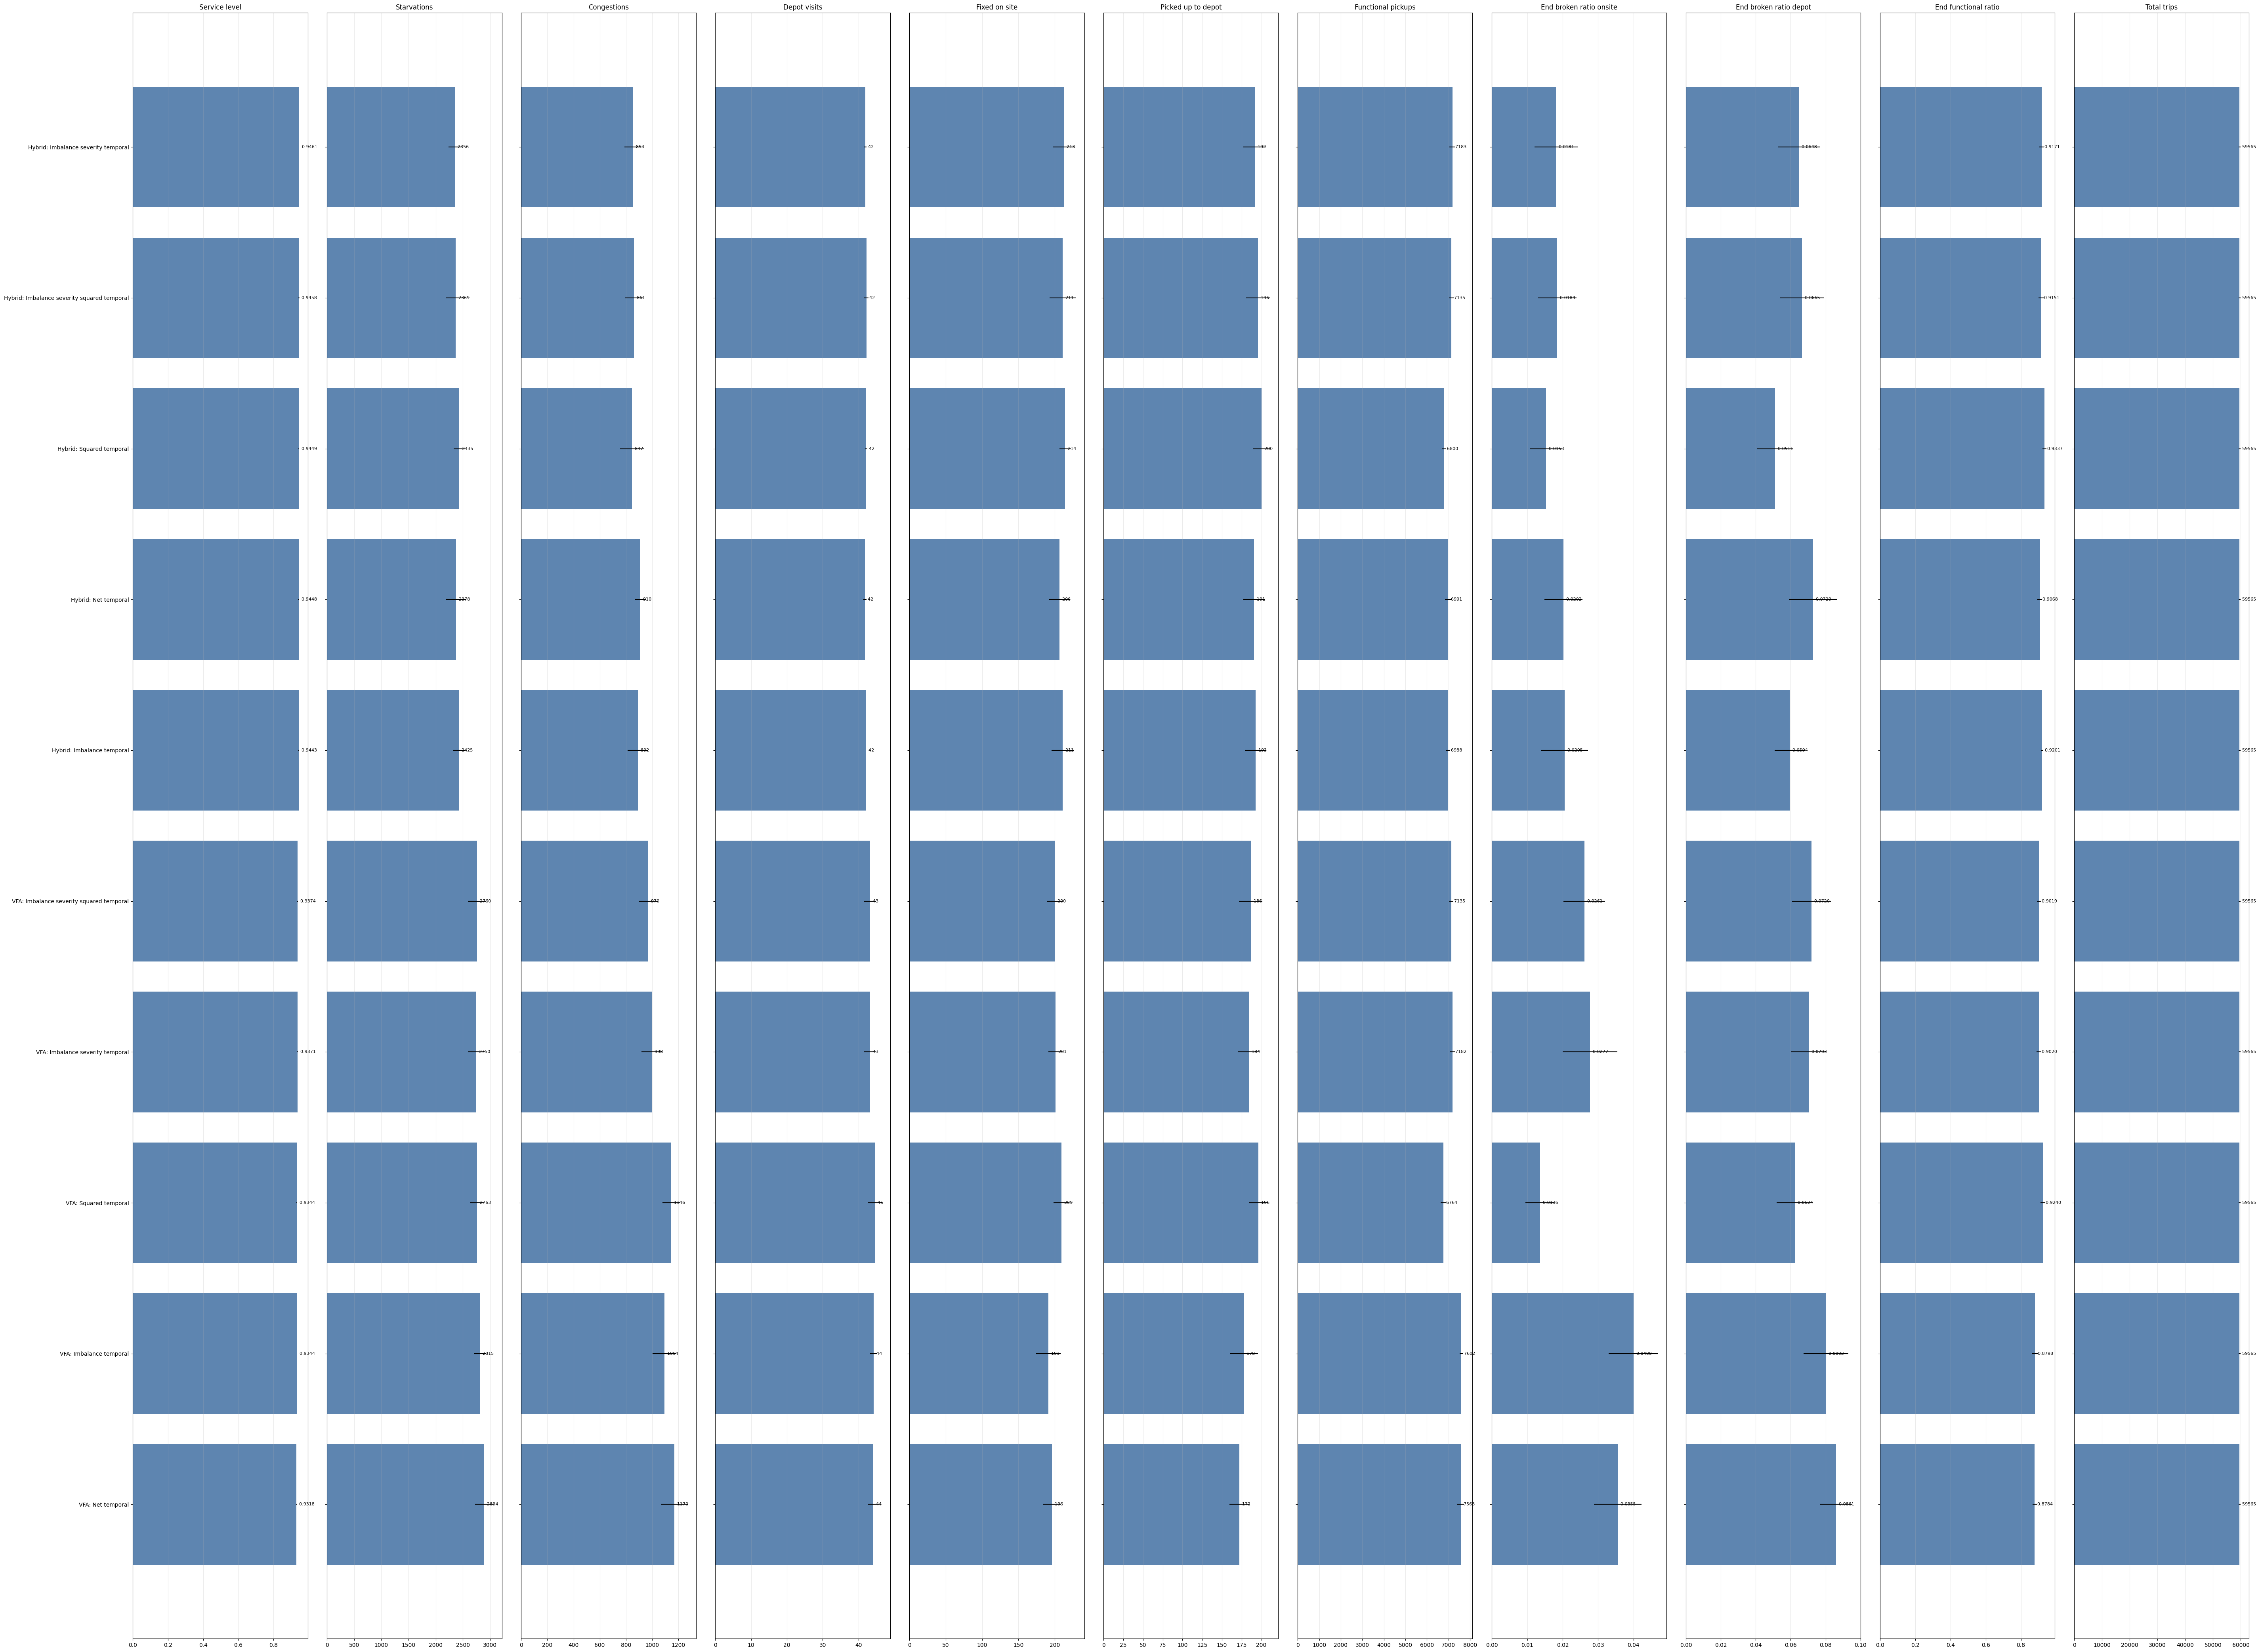

In [206]:
fig = plot_metric_bars(summary, METRICS, SORT_BY)
plt.show()

## Save Outputs

In [207]:
if SAVE_OUTPUTS or SAVE_SUMMARY_TABLE_CSV:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if SAVE_SUMMARY_TABLE_CSV:
    summary_table_path = OUTPUT_DIR / "run_log_results_summary_table.csv"
    summary_table_csv = summary_table.copy()
    summary_table_csv.columns = [
        col[0] if col[1] == "" else f"{col[0]}_{col[1]}"
        for col in summary_table_csv.columns.to_flat_index()
    ]
    summary_table_csv.to_csv(summary_table_path)
    print(f"Saved summary table: {summary_table_path.relative_to(WORKSPACE_ROOT)}")

if SAVE_OUTPUTS:
    raw_path = OUTPUT_DIR / "run_log_results_raw.csv"
    summary_path = OUTPUT_DIR / "run_log_results_summary.csv"
    figure_path = OUTPUT_DIR / "run_log_results_comparison.png"

    df.to_csv(raw_path, index=False)
    summary.to_csv(summary_path, index=False)
    fig.savefig(figure_path, dpi=220, bbox_inches="tight")

    print(f"Saved raw data: {raw_path.relative_to(WORKSPACE_ROOT)}")
    print(f"Saved summary:  {summary_path.relative_to(WORKSPACE_ROOT)}")
    print(f"Saved figure:   {figure_path.relative_to(WORKSPACE_ROOT)}")

Saved summary table: run_logs/plots/baseline_candidates/run_log_results_summary_table.csv
Saved raw data: run_logs/plots/baseline_candidates/run_log_results_raw.csv
Saved summary:  run_logs/plots/baseline_candidates/run_log_results_summary.csv
Saved figure:   run_logs/plots/baseline_candidates/run_log_results_comparison.png
